In [5]:
import numpy as np
import matplotlib.pyplot as plt

Le vecteur des poids (w) est : [0.74478126 0.59598525]
Le biais (b) est : -0.06300000000000004
Prédictions sur les 5 premiers points : [1. 1. 1. 1. 1.]
Les vraies classes : [1. 1. 1. 1. 1.]


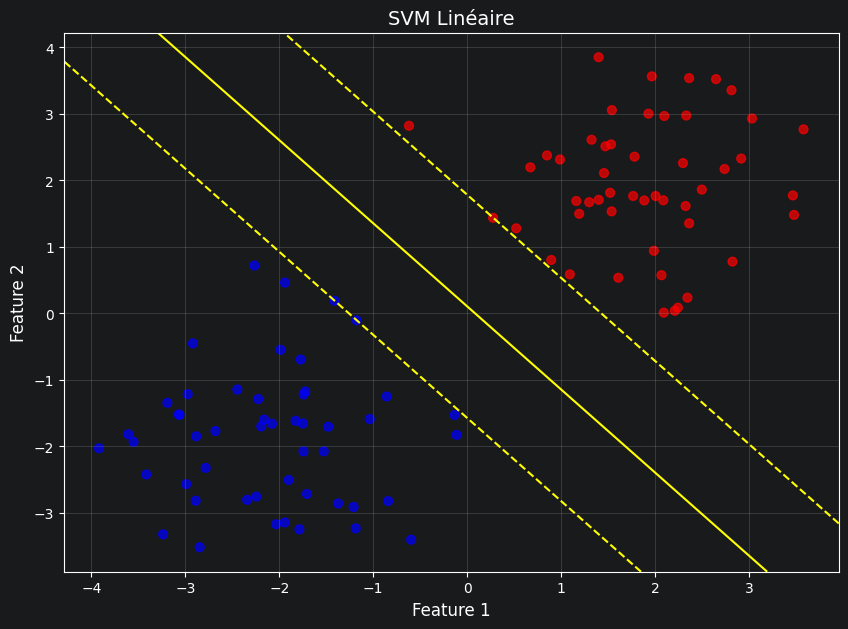

In [6]:
# GÉNÉRATION DU DATASET
# On fixe la graine aléatoire pour obtenir toujours les mêmes données à chaque exécution.
np.random.seed(42)

# Nombre total de points
n_samples = 100

# On va créer 2 groupes :
#  Groupe 1 : centré autour de [2, 2], classe +1
#  Groupe 2 : centré autour de [-2, -2], classe -1

# Génération de 50 points pour la classe +1
X_classe_positive = np.random.randn(n_samples // 2, 2) + np.array([2, 2])
y_classe_positive = np.ones(n_samples // 2)

# Génération de 50 points pour la classe -1
X_classe_negative = np.random.randn(n_samples // 2, 2) + np.array([-2, -2])
y_classe_negative = -np.ones(n_samples // 2)

# Regroupement de toutes les données
X = np.vstack((X_classe_positive, X_classe_negative))
y = np.concatenate((y_classe_positive, y_classe_negative))

# FONCTION D'ENTRAÎNEMENT DU SVM
def entrainer_svm(X, y, learning_rate=0.001, lambda_param=0.01, n_iterations=1000):
    """
    Entraîne un SVM linéaire from scratch avec une méthode proche
    de la descente de gradient.

    Paramètres :
    - X : matrice des caractéristiques
    - y : vecteur des classes (+1 ou -1)
    - learning_rate : vitesse d'apprentissage
    - lambda_param : paramètre de régularisation
    - n_iterations : nombre d'itérations d'entraînement

    Retour :
    - w : vecteur des poids
    - b : biais
    """

    # Nombre d'exemples et nombre de variables
    n_samples, n_features = X.shape

    # Initialisation des paramètres du modèle
    w = np.zeros(n_features)
    b = 0

    # Boucle principale d'entraînement
    for _ in range(n_iterations):
        for idx, x_i in enumerate(X):

            # Vérifier si le point respecte la condition de marge : y_i * (w.x_i + b) >= 1
            condition = y[idx] * (np.dot(x_i, w) + b) >= 1

            if condition:
                # Si le point est bien classé et en dehors de la marge, on applique seulement la régularisation sur w
                dw = 2 * lambda_param * w
                w -= learning_rate * dw

            else:
                # Si le point est mal classé ou dans la marge, on ajuste w et b
                dw = 2 * lambda_param * w - (x_i * y[idx])
                db = -y[idx]

                w -= learning_rate * dw
                b -= learning_rate * db

    return w, b


# FONCTION DE PRÉDICTION

def predire_svm(X, w, b):
    """
    Prédit la classe (+1 ou -1) pour un ou plusieurs points.
    """
    approximation = np.dot(X, w) + b
    return np.sign(approximation)


# ENTRAÎNEMENT DU MODÈLE
# On entraîne notre SVM pour trouver la meilleure droite séparatrice
poids_w, biais_b = entrainer_svm(
    X, y,
    learning_rate=0.001,
    lambda_param=0.01,
    n_iterations=1000
)

# Affichage des paramètres trouvés
print(f"Le vecteur des poids (w) est : {poids_w}")
print(f"Le biais (b) est : {biais_b}")

# Test sur les 5 premiers points
predictions = predire_svm(X[:5], poids_w, biais_b)

print(f"Prédictions sur les 5 premiers points : {predictions}")
print(f"Les vraies classes : {y[:5]}")


# REPRÉSENTATION GRAPHIQUE

plt.figure(figsize=(10, 7))

# Affichage des points du dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=40, alpha=0.7)

# On récupère l'axe actuel pour créer la grille
ax = plt.gca()

# Limites du graphique
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Création d'une grille de points pour dessiner l'hyperplan
xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# On transforme la grille en une liste de points (x, y)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Calcul de la valeur de la fonction de décision : w.x + b
Z = (np.dot(xy, poids_w) + biais_b).reshape(XX.shape)

# Tracer :
# - la droite centrale : Z = 0
# - les marges : Z = -1 et Z = 1
ax.contour(
    XX, YY, Z,
    colors='yellow',
    levels=[-1, 0, 1],
    linestyles=['--', '-', '--']
)

# Titres et habillage
plt.title("SVM Linéaire", fontsize=14)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()